# 산학프로젝트
**제조 공정 품질 불량 예측**

# 05_Operating_Point

- 운영점(검사 물량 k, Threshold) 확정과 최종 모델 선택
- 평가 프로토콜: 04_6에서 저장한 5-fold × 3반복 OOF 확률 재사용, 모델 재학습 없음
- 주의: 04_6과 같은 수치 체계. 단일 홀드아웃 수치는 쓰지 않음

## import

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT=Path.cwd().parent if Path.cwd().name=='data' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 공통 평가 함수
from utils.model_evaluation import recall_at_k_table

# 그래프 한글 표시
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False

## 경로설정

In [2]:
if Path.cwd().name!='data':
    os.chdir('data')

## 데이터 불러오기

- 04_6이 저장한 반복별 OOF 확률 사용. 컬럼은 `모델 | 특성셋 | rep번호` 형식
- 04_6 결과에 따라 오토인코더 특성은 최종 모델에 넣지 않으므로 `원본`만 사용

In [3]:
oof_proba=pd.read_csv('04_6_AutoEncoder_CV_Validation_oof_proba.csv', index_col=0)
print(f'{oof_proba.shape[0]}행, 확률 컬럼 {oof_proba.shape[1]-1}개')

y_all=oof_proba['PassOrFail'].to_numpy()
n_total=len(y_all)
n_defect=y_all.sum()
print(f'불량 {n_defect}건 / 기저 불량률 {n_defect/n_total:.4%}')

# 컬럼명을 (모델, 특성셋, 반복)으로 분해
proba_columns=[]
for column in oof_proba.columns.drop('PassOrFail'):
    model_name, set_name, repeat=[part.strip() for part in column.split('|')]
    proba_columns.append({'Column': column, 'Model': model_name, 'Feature Set': set_name,
                          'Repeat': int(repeat.replace('rep', ''))})

proba_columns=pd.DataFrame(proba_columns)
proba_columns=proba_columns[proba_columns['Feature Set']=='원본']
print(f"사용 모델 {proba_columns['Model'].nunique()}개, 반복 {proba_columns['Repeat'].nunique()}회")
proba_columns

5230행, 확률 컬럼 30개
불량 60건 / 기저 불량률 1.1472%
사용 모델 5개, 반복 3회


,Column,Model,Feature Set,Repeat
0,RandomForest Balanced | 원본 | rep1,RandomForest Balanced,원본,1
1,RandomForest SMOTE St=0.1 | 원본 | rep1,RandomForest SMOTE St=0.1,원본,1
2,Bagging SMOTE St=0.1 | 원본 | rep1,Bagging SMOTE St=0.1,원본,1
3,XGBoost | 원본 | rep1,XGBoost,원본,1
4,XGBoost SMOTE St=0.1 | 원본 | rep1,XGBoost SMOTE St=0.1,원본,1
10,RandomForest Balanced | 원본 | rep2,RandomForest Balanced,원본,2
11,RandomForest SMOTE St=0.1 | 원본 | rep2,RandomForest SMOTE St=0.1,원본,2
12,Bagging SMOTE St=0.1 | 원본 | rep2,Bagging SMOTE St=0.1,원본,2
13,XGBoost | 원본 | rep2,XGBoost,원본,2
14,XGBoost SMOTE St=0.1 | 원본 | rep2,XGBoost SMOTE St=0.1,원본,2


## 1. 검사 물량 후보별 성능

- 검사 인력이 감당할 수 있는 물량을 **k**로 두고, 그 물량에서 각 모델이 불량을 얼마나 잡는지 확인
- 반복 3회의 **평균과 표준편차**를 함께 봄

In [4]:
inspect_ratios=[0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2]

operating_rows=pd.concat(
    [recall_at_k_table(y_all, oof_proba[row['Column']].to_numpy(), inspect_ratios=inspect_ratios,
                       extra_columns={'Model': row['Model'], 'Repeat': row['Repeat']})
     for _, row in proba_columns.iterrows()],
    ignore_index=True,
)

operating_df=operating_rows.groupby(['Model', '검사 비율']).agg(**{
    '검사 수': ('검사 수', 'first'),
    'Recall@k 평균': ('Recall@k', 'mean'),
    'Recall@k 표준편차': ('Recall@k', 'std'),
    'Precision@k 평균': ('Precision@k', 'mean'),
    'Lift 평균': ('Lift', 'mean'),
})
operating_df.round(4)

검사 수  Recall@k 평균  Recall@k 표준편차  \
Model                     검사 비율                                     
Bagging SMOTE St=0.1      0.01     52       0.3056         0.0096   
                          0.02    105       0.3778         0.0347   
                          0.03    157       0.4167         0.0500   
                          0.05    262       0.4889         0.0918   
                          0.07    366       0.5611         0.0674   
                          0.10    523       0.6944         0.1018   
                          0.15    784       0.8222         0.0255   
                          0.20   1046       0.9611         0.0255   
RandomForest Balanced     0.01     52       0.3222         0.0347   
                          0.02    105       0.4056         0.0419   
                          0.03    157       0.4500         0.0333   
                          0.05    262       0.5333         0.0441   
                          0.07    366       0.6833         0.0289   
                          0.10    523       0.7889         0.0096   
                          0.15    784       0.8611         0.0255   
                          0.20   1046       0.9389         0.0255   
RandomForest SMOTE St=0.1 0.01     52       0.2833         0.0167   
                          0.02    105       0.3444         0.0347   
                          0.03    157       0.4167         0.0441   
                          0.05    262       0.5111         0.0419   
                          0.07    366       0.6111         0.0536   
                          0.10    523       0.7111         0.0585   
                          0.15    784       0.8667         0.0167   
                          0.20   1046       0.9278         0.0192   
XGBoost                   0.01     52       0.2889         0.0347   
                          0.02    105       0.3944         0.0255   
                          0.03    157       0.4556         0.0096   
                          0.05    262       0.5444         0.0481   
                          0.07    366       0.6556         0.0752   
                          0.10    523       0.7500         0.0500   
                          0.15    784       0.8500         0.0333   
                          0.20   1046       0.8889         0.0255   
XGBoost SMOTE St=0.1      0.01     52       0.2889         0.0347   
                          0.02    105       0.3722         0.0347   
                          0.03    157       0.4611         0.0096   
                          0.05    262       0.5667         0.0167   
                          0.07    366       0.6722         0.0419   
                          0.10    523       0.7611         0.0419   
                          0.15    784       0.8500         0.0333   
                          0.20   1046       0.8889         0.0192   

                                 Precision@k 평균  Lift 평균  
Model                     검사 비율                           
Bagging SMOTE St=0.1      0.01           0.3526  30.7318  
                          0.02           0.2159  18.8169  
                          0.03           0.1592  13.8800  
                          0.05           0.1120   9.7591  
                          0.07           0.0920   8.0181  
                          0.10           0.0797   6.9444  
                          0.15           0.0629   5.4850  
                          0.20           0.0551   4.8056  
RandomForest Balanced     0.01           0.3718  32.4081  
                          0.02           0.2317  20.2005  
                          0.03           0.1720  14.9904  
                          0.05           0.1221  10.6463  
                          0.07           0.1120   9.7646  
                          0.10           0.0905   7.8889  
                          0.15           0.0659   5.7444  
                          0.20           0.0539   4.6944  
RandomForest SMOTE St=0.1 0.01           0.3269  28.4968  
             

In [5]:
# 검사 물량별 Recall@k 비교 (행: 모델, 열: 검사 비율)
recall_pivot=operating_df['Recall@k 평균'].unstack('검사 비율')
recall_pivot.round(3)

검사 비율,0.01,0.02,0.03,0.05,0.07,0.10,0.15,0.20
Model,,,,,,,,
Bagging SMOTE St=0.1,0.306,0.378,0.417,0.489,0.561,0.694,0.822,0.961
RandomForest Balanced,0.322,0.406,0.450,0.533,0.683,0.789,0.861,0.939
RandomForest SMOTE St=0.1,0.283,0.344,0.417,0.511,0.611,0.711,0.867,0.928
XGBoost,0.289,0.394,0.456,0.544,0.656,0.750,0.850,0.889
XGBoost SMOTE St=0.1,0.289,0.372,0.461,0.567,0.672,0.761,0.850,0.889


## 2. 일일 검사 물량 환산

- 비율만으로는 현장에서 판단하기 어려우므로 하루 생산량 기준 건수로 환산
- 라벨 데이터 기간의 실제 생산량으로 하루 평균 계산

In [6]:
# 02_EDA에서 저장한 전처리 데이터 (생산량 집계에만 사용)
labeled=pd.read_csv('labeled_modeling.csv', index_col=0)

production_date=pd.to_datetime(labeled['TimeStamp']).dt.date
daily_counts=production_date.value_counts().sort_index()

n_days=len(daily_counts)
daily_mean=daily_counts.mean()
print(f'생산일 {n_days}일, 하루 평균 {daily_mean:.0f}건 (최소 {daily_counts.min()}건, 최대 {daily_counts.max()}건)')
print(f'하루 평균 불량 기대값 {daily_mean*n_defect/n_total:.2f}건')

daily_rows=[]
for ratio in inspect_ratios:
    for model_name in recall_pivot.index:
        recall_at_k=recall_pivot.loc[model_name, ratio]
        daily_rows.append({
            'Model': model_name,
            '검사 비율': ratio,
            '하루 검사 건수': round(daily_mean*ratio, 1),
            'Recall@k': recall_at_k,
            '하루 검출 불량': round(daily_mean*n_defect/n_total*recall_at_k, 2),
            '하루 헛검사': round(daily_mean*ratio-daily_mean*n_defect/n_total*recall_at_k, 1),
        })

daily_df=pd.DataFrame(daily_rows)
daily_df.pivot_table(index='검사 비율', columns='Model', values='하루 검출 불량').round(2)

생산일 13일, 하루 평균 402건 (최소 1건, 최대 926건)
하루 평균 불량 기대값 4.62건


Model,Bagging SMOTE St=0.1,RandomForest Balanced,RandomForest SMOTE St=0.1,XGBoost,XGBoost SMOTE St=0.1
검사 비율,,,,,
0.01,1.41,1.49,1.31,1.33,1.33
0.02,1.74,1.87,1.59,1.82,1.72
0.03,1.92,2.08,1.92,2.10,2.13
0.05,2.26,2.46,2.36,2.51,2.62
0.07,2.59,3.15,2.82,3.03,3.10
0.10,3.21,3.64,3.28,3.46,3.51
0.15,3.79,3.97,4.00,3.92,3.92
0.20,4.44,4.33,4.28,4.10,4.10


## 3. 검사 물량별 최적 모델

- 04_6에서 **AP 1위(RandomForest Balanced)** 와 **검사 물량 일부 구간 1위(XGBoost SMOTE St=0.1)** 가 갈림 → k를 정하면 모델이 따라 결정됨

In [7]:
best_rows=[]
for ratio in inspect_ratios:
    column=recall_pivot[ratio]
    best_model=column.idxmax()
    runner_up=column.drop(best_model).idxmax()

    best_rows.append({
        '검사 비율': ratio,
        '1위 모델': best_model,
        '1위 Recall@k': column[best_model],
        '2위 모델': runner_up,
        '2위 Recall@k': column[runner_up],
        '차이': column[best_model]-column[runner_up],
        '차이 불량 건수': round((column[best_model]-column[runner_up])*n_defect, 1),
    })

best_df=pd.DataFrame(best_rows)
best_df.round(4)

,검사 비율,1위 모델,1위 Recall@k,2위 모델,2위 Recall@k,차이,차이 불량 건수
0,0.01,RandomForest Balanced,0.3222,Bagging SMOTE St=0.1,0.3056,0.0167,1.0
1,0.02,RandomForest Balanced,0.4056,XGBoost,0.3944,0.0111,0.7
2,0.03,XGBoost SMOTE St=0.1,0.4611,XGBoost,0.4556,0.0056,0.3
3,0.05,XGBoost SMOTE St=0.1,0.5667,XGBoost,0.5444,0.0222,1.3
4,0.07,RandomForest Balanced,0.6833,XGBoost SMOTE St=0.1,0.6722,0.0111,0.7
5,0.10,RandomForest Balanced,0.7889,XGBoost SMOTE St=0.1,0.7611,0.0278,1.7
6,0.15,RandomForest SMOTE St=0.1,0.8667,RandomForest Balanced,0.8611,0.0056,0.3
7,0.20,Bagging SMOTE St=0.1,0.9611,RandomForest Balanced,0.9389,0.0222,1.3


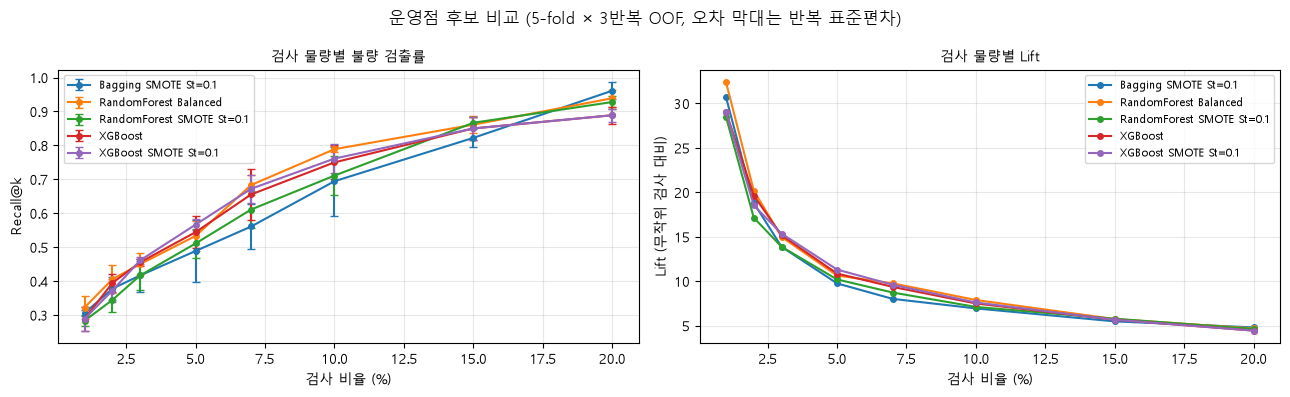

In [8]:
fig, axes=plt.subplots(1, 2, figsize=(13, 4))

for model_name in recall_pivot.index:
    group=operating_df.loc[model_name]
    axes[0].errorbar(group.index*100, group['Recall@k 평균'], yerr=group['Recall@k 표준편차'],
                     marker='o', markersize=4, capsize=3, label=model_name)
    axes[1].plot(group.index*100, group['Lift 평균'], marker='o', markersize=4, label=model_name)

axes[0].set_ylabel('Recall@k')
axes[0].set_title('검사 물량별 불량 검출률', fontsize=10)
axes[1].set_ylabel('Lift (무작위 검사 대비)')
axes[1].set_title('검사 물량별 Lift', fontsize=10)

for ax in axes:
    ax.set_xlabel('검사 비율 (%)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('운영점 후보 비교 (5-fold × 3반복 OOF, 오차 막대는 반복 표준편차)')
plt.tight_layout()
plt.show()

## 4. Threshold 환산

- 대시보드는 확률 Threshold로 구현되므로 각 검사 물량에 해당하는 확률 컷을 계산
- 반복마다 컷이 달라지는 폭도 함께 확인. 이 폭이 크면 Threshold 고정보다 물량 기준 운영이 안전

In [9]:
threshold_rows=[]
for _, row in proba_columns.iterrows():
    proba=oof_proba[row['Column']].to_numpy()

    for ratio in inspect_ratios:
        n_inspect=max(1, round(n_total*ratio))
        # 상위 n_inspect번째 확률이 그 물량에 해당하는 컷
        cutoff=np.sort(proba)[::-1][n_inspect-1]
        threshold_rows.append({'Model': row['Model'], 'Repeat': row['Repeat'],
                               '검사 비율': ratio, 'Threshold': cutoff})

threshold_df=pd.DataFrame(threshold_rows).groupby(['Model', '검사 비율'])['Threshold'].agg(['mean', 'std', 'min', 'max'])
threshold_df.columns=[f'Threshold {stat}' for stat in threshold_df.columns]
threshold_df.round(4)

Threshold mean  Threshold std  Threshold min  \
Model                     검사 비율                                                 
Bagging SMOTE St=0.1      0.01           0.2879         0.0259         0.2618   
                          0.02           0.1917         0.0047         0.1880   
                          0.03           0.1589         0.0045         0.1557   
                          0.05           0.1238         0.0015         0.1220   
                          0.07           0.0972         0.0019         0.0957   
                          0.10           0.0712         0.0025         0.0695   
                          0.15           0.0417         0.0021         0.0400   
                          0.20           0.0204         0.0005         0.0200   
RandomForest Balanced     0.01           0.6386         0.0124         0.6248   
                          0.02           0.4969         0.0058         0.4904   
                          0.03           0.4215         0.0038         0.4174   
                          0.05           0.3160         0.0044         0.3123   
                          0.07           0.2495         0.0065         0.2433   
                          0.10           0.1627         0.0004         0.1623   
                          0.15           0.0794         0.0013         0.0781   
                          0.20           0.0349         0.0017         0.0334   
RandomForest SMOTE St=0.1 0.01           0.2844         0.0135         0.2767   
                          0.02           0.1856         0.0069         0.1800   
                          0.03           0.1533         0.0058         0.1500   
                          0.05           0.1100         0.0033         0.1067   
                          0.07           0.0822         0.0038         0.0800   
                          0.10           0.0567         0.0033         0.0533   
                          0.15           0.0267         0.0000         0.0267   
                          0.20           0.0100         0.0000         0.0100   
XGBoost                   0.01           0.1147         0.0117         0.1016   
                          0.02           0.0245         0.0073         0.0170   
                          0.03           0.0099         0.0015         0.0085   
                          0.05           0.0024         0.0001         0.0023   
                          0.07           0.0010         0.0001         0.0009   
                          0.10           0.0004         0.0000         0.0003   
                          0.15           0.0001         0.0000         0.0001   
                          0.20           0.0000         0.0000         0.0000   
XGBoost SMOTE St=0.1      0.01           0.1659         0.0310         0.1441   
                          0.02           0.0293         0.0032         0.0261   
                          0.03           0.0117         0.0022         0.0092   
                          0.05           0.0034         0.0005         0.0029   
                          0.07           0.0013         0.0001         0.0012   
                          0.10           0.0005         0.0000         0.0004   
                          0.15           0.0001         0.0000         0.0001   
                          0.20           0.0001         0.0000         0.0001   

                                 Threshold max  
Model                     검사 비율                 
Bagging SMOTE St=0.1      0.01          0.3135  
                          0.02          0.1970  
                          0.03          0.1640  
                          0.05          0.1247  
                          0.07          0.0993  
                          0.10          0.0740  
                          0.15          0.0440  
                          0.20          0.0210  
RandomForest Balanced     0.01          0.6489  
                          0.02          0.5015  
                          0.03          0.

## 결과 저장

In [10]:
operating_df.to_csv('05_Operating_Point_by_ratio.csv')
daily_df.to_csv('05_Operating_Point_daily.csv', index=False)
best_df.to_csv('05_Operating_Point_best_model.csv', index=False)
threshold_df.to_csv('05_Operating_Point_threshold.csv')
print('저장 완료')

저장 완료


## 해석과 권장 운영점

### 검사 물량별 성능 (5-fold × 3반복 OOF, 하루 평균 생산 402건 기준)

| 검사 비율 | 하루 검사 건수 | Recall@k (RF Balanced) | 하루 검출 불량 | 하루 헛검사 |
| --- | --- | --- | --- | --- |
| 1% | 4건 | 0.322 | 1.49건 | 2.5건 |
| 3% | 12건 | 0.450 | 2.08건 | 10.0건 |
| 5% | 20건 | 0.533 | 2.46건 | 17.7건 |
| 7% | 28건 | 0.683 | 3.15건 | 25.0건 |
| **10%** | **40건** | **0.789** | **3.64건** | **36.6건** |
| 15% | 60건 | 0.861 | 3.97건 | 56.4건 |
| 20% | 80건 | 0.939 | 4.33건 | 76.1건 |

하루 평균 생산 402건, 하루 평균 불량 4.62건 기준 (라벨 데이터 13일)

### 모델 선택: RandomForest Balanced

검사 물량별 1위 모델이 바뀌지만 **차이가 불량 0.3 ~ 1.7건 수준**이라 결정적이지 않음

| 검사 비율 | 1위 모델 | 2위와 차이 (불량 건수) |
| --- | --- | --- |
| 1% | RandomForest Balanced | 1.0건 |
| 2% | RandomForest Balanced | 0.7건 |
| 3% | XGBoost SMOTE St=0.1 | 0.3건 |
| 5% | XGBoost SMOTE St=0.1 | 1.3건 |
| 7% | RandomForest Balanced | 0.7건 |
| 10% | RandomForest Balanced | 1.7건 |
| 15% | RandomForest SMOTE St=0.1 | 0.3건 |
| 20% | Bagging SMOTE St=0.1 | 1.3건 |

**최종 모델은 RandomForest Balanced로 결정**

1. 8개 물량 구간에서 **1위 4회, 2위 3회**로 전 구간이 안정적임. XGBoost SMOTE가 앞서는 3 ~ 5% 구간에서도 하루 검출 불량 차이는 **0.3 ~ 1.3건**임
2. **AP도 1위**임 (0.3931 ± 0.1107)
3. **운영 지점인 10% 구간에서 2위와 격차가 가장 큼** (0.789 vs 0.761, 하루 1.7건)
4. **확률 스케일이 대시보드에서 다룰 수 있는 범위**임. 검사 물량 1 ~ 20%에 해당하는 Threshold가 0.64 ~ 0.03으로 퍼져 있어 작업자가 슬라이더로 조절 가능. XGBoost SMOTE St=0.1은 같은 구간이 0.174 ~ 0.0001이어서 UI에서 다루기 어렵고, 확률값을 그대로 보여주면 "불량 확률 0.1%"처럼 읽혀 오해를 부름
5. 이미 `models/rf_part_balanced.pkl`로 저장돼 있어 **예측 서버 연동이 바로 가능**함

### 권장 Threshold (RandomForest Balanced)

| 검사 비율 | Threshold 평균 | 반복 간 표준편차 |
| --- | --- | --- |
| 1% | 0.639 | 0.012 |
| 3% | 0.422 | 0.004 |
| 5% | 0.316 | 0.004 |
| 7% | 0.249 | 0.007 |
| **10%** | **0.163** | **0.000** |
| 15% | 0.079 | 0.001 |
| 20% | 0.035 | 0.002 |

반복 간 표준편차가 **0.012 이하**로 안정적이므로 Threshold 고정 방식으로도 운영 가능. 다만 알람 건수는 물량으로 고정되지 않으므로, 검사 인력이 정해져 있으면 **상위 k% 방식이 안전**함

### 대시보드 반영 사항

- 기본 Threshold **0.163** (검사 물량 10%, 불량 검출률 79%)을 권장값으로 제시하고, 작업자가 조정할 수 있게 함
- Threshold 조절 화면에 **"이 값으로 하루 약 40건 검사, 불량 3.6건 검출 예상"** 처럼 물량과 검출 기대값을 함께 표시
- 검사 인력이 하루 20건뿐이면 Threshold **0.316(5%)** 이고 검출률은 **53%** 로 하락. 이 교환관계를 화면에 명시
- 오토인코더는 04_6 결과에 따라 적용하지 않으므로, 예측 서버는 `rf_part_balanced.pkl`과 `feature_columns.pkl`만 사용

### 주의

- 여기 수치는 라벨 데이터 5230건(불량 60건) 기준이며, 반복 3회 표준편차는 **0.01 ~ 0.10**임. 실제 운영에서는 기간과 로트에 따라 이 폭으로 변동
- 하루 평균 402건은 라벨 데이터 13일 기준이며 **일별 편차가 큼**(최소 1건, 최대 926건). 물량 기준 운영 시 일별 알람 수도 그만큼 변동
- 검사 물량 15% 이상 구간의 Recall@k 0.86 이상은 **모델 성능이 아니라 검사 물량을 늘린 결과**임. Lift는 10%에서 7.9배, 20%에서 4.7배로 하락
- 이 수치는 **무작위 CV 기준**임. 시간 순서를 지킨 운영 조건 성능은 07_2 참고 (Recall@10% 0.628)
